# 07 · Explainability (SHAP)

**Phase 15 of the project plan.**

We explain the best **tree** model saved by `05_tree_models.ipynb` (Random Forest / XGBoost / LightGBM — whichever won) using SHAP's `TreeExplainer`, which is fast and computes exact Shapley values for tree ensembles. We deliberately explain the tree model rather than the LSTM/GRU from `06`: `TreeExplainer` is exact and cheap here, whereas explaining recurrent nets needs slower, approximate explainers (`DeepExplainer`/`KernelExplainer`) — worth a follow-up notebook later, but not necessary to get useful explanations now.

Sensor names are mapped back to their physical meaning (`src/data_loader.SENSOR_INFO`) throughout, so explanations read in engineering terms, not `sensor_11`.


In [1]:
import sys
sys.path.insert(0, "..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src import data_loader as dl

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
SUBSET = "FD001"

model = joblib.load(f"{MODELS_DIR}/best_model_{SUBSET}.joblib")
meta = joblib.load(f"{MODELS_DIR}/best_model_{SUBSET}_meta.joblib")
feature_cols = meta["feature_cols"]
print("Explaining model:", meta["model_name"])

val = pd.read_parquet(f"{PROCESSED_DIR}/val_{SUBSET}_features.parquet")
X_val = val[feature_cols]


C:\Users\BobyDubey\Downloads\Ambika\aircraft-rul-prognostics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explaining model: XGBoost


## Global explanation

A random sample of validation rows (SHAP scales with sample size; 500 rows is plenty to see the overall pattern while staying fast). The beeswarm plot shows, per feature, how its value (color) relates to its effect on the predicted RUL (x-axis); the bar plot ranks features by mean |SHAP value|.


In [2]:
SAMPLE_SIZE = 500
X_sample = X_val.sample(n=min(SAMPLE_SIZE, len(X_val)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)
shap_values


.values =
array([[ 2.4868790e-03, -2.6850009e-03, -7.2984286e-03, ...,
         0.0000000e+00,  0.0000000e+00, -1.0471546e+01],
       [-6.3840948e-02,  7.7652574e-02, -2.2668657e-03, ...,
         0.0000000e+00,  0.0000000e+00,  1.0675959e+01],
       [-1.3582355e-02, -3.0901795e-03,  1.7751179e-03, ...,
         0.0000000e+00,  0.0000000e+00,  9.6589212e+00],
       ...,
       [-6.3859662e-03,  2.5561036e-04, -7.4246645e-02, ...,
         0.0000000e+00,  0.0000000e+00, -3.2826424e+01],
       [-4.0169731e-03,  4.3570120e-03, -1.0088654e-01, ...,
         0.0000000e+00,  0.0000000e+00, -3.2993248e+01],
       [-2.6910597e-02, -1.7850216e-05, -1.7554851e-03, ...,
         0.0000000e+00,  0.0000000e+00,  5.1618366e+00]],
      shape=(500, 290), dtype=float32)

.base_values =
array([106.9812, 106.9812, 106.9812, 106.9812, 106.9812, 106.9812,
       106.9812, 106.9812, 106.9812, 106.9812, 106.9812, 106.9812,
       106.9812, 106.9812, 106.9812, 106.9812, 106.9812, 106.9812,
       106.98

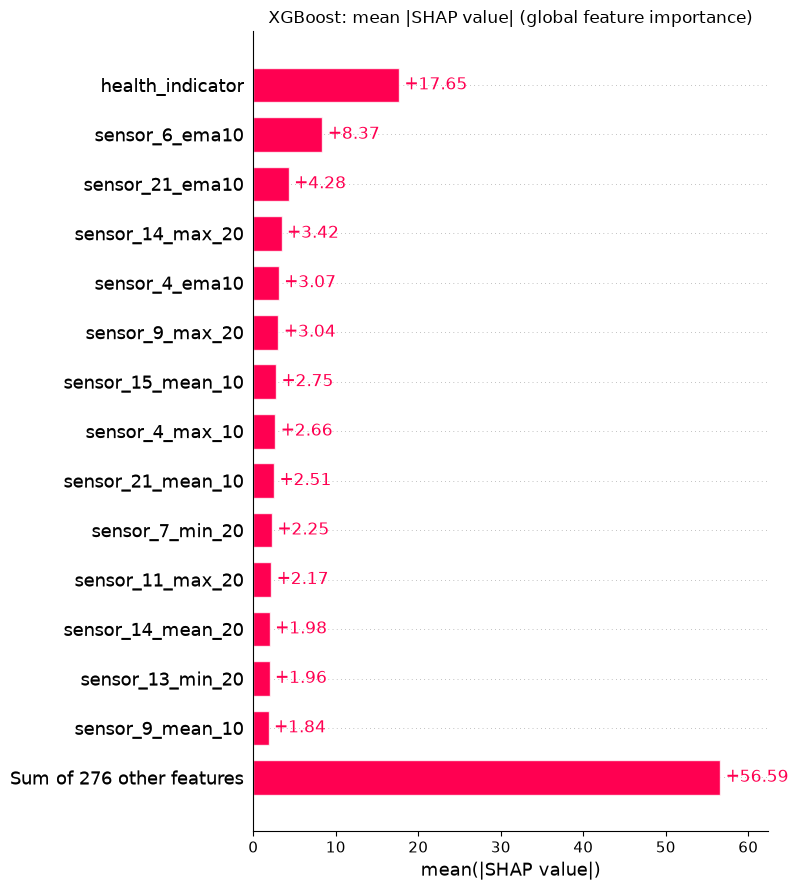

In [3]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title(f"{meta['model_name']}: mean |SHAP value| (global feature importance)")
plt.tight_layout()
plt.show()


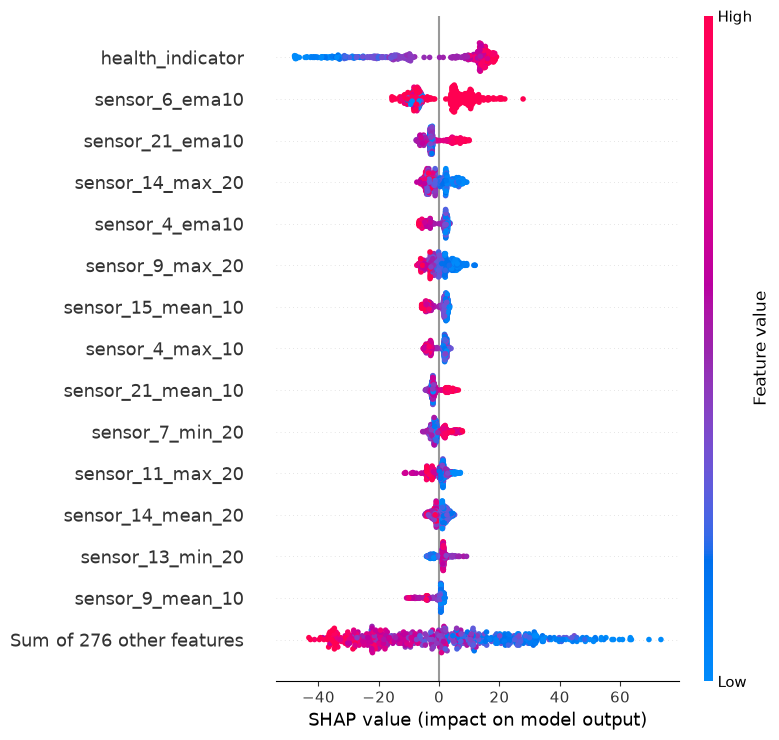

In [4]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()


## Mapping top features to physical sensors

Engineered feature names (e.g. `sensor_11_mean_10`) encode `<sensor>_<stat>_<window>`; the base sensor name maps to its PHM08-paper symbol/description via `src/data_loader.SENSOR_INFO`.


In [5]:
def base_sensor_of(feature_name):
    for sensor_col in dl.SENSOR_COLS:
        if feature_name == sensor_col or feature_name.startswith(f"{sensor_col}_"):
            return sensor_col
    return None

mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
top_features = mean_abs_shap.head(15).to_frame("mean_abs_shap")
top_features["base_sensor"] = [base_sensor_of(f) for f in top_features.index]
top_features["symbol"] = [dl.SENSOR_INFO.get(s, {}).get("symbol") for s in top_features["base_sensor"]]
top_features["description"] = [dl.SENSOR_INFO.get(s, {}).get("description") for s in top_features["base_sensor"]]
top_features


,mean_abs_shap,base_sensor,symbol,description
health_indicator,17.650854,NaN,NaN,NaN
sensor_6_ema10,8.372910,sensor_6,P15,Total pressure in bypass duct
sensor_21_ema10,4.280605,sensor_21,W32,LPT coolant bleed
sensor_14_max_20,3.418839,sensor_14,NRc,Corrected core speed
sensor_4_ema10,3.070999,sensor_4,T50,Total temperature at LPT outlet
sensor_9_max_20,3.040651,sensor_9,Nc,Physical core speed
sensor_15_mean_10,2.749223,sensor_15,BPR,Bypass ratio
sensor_4_max_10,2.657491,sensor_4,T50,Total temperature at LPT outlet
sensor_21_mean_10,2.505960,sensor_21,W32,LPT coolant bleed
sensor_7_min_20,2.251415,sensor_7,P30,Total pressure at HPC outlet


## Local explanation — one engine, close to failure

Picking a validation row with low true RUL and showing exactly which features pushed the prediction up or down for that single observation, in plain language.


Engine 19, cycle 158: true RUL = 0, predicted RUL = 7.6


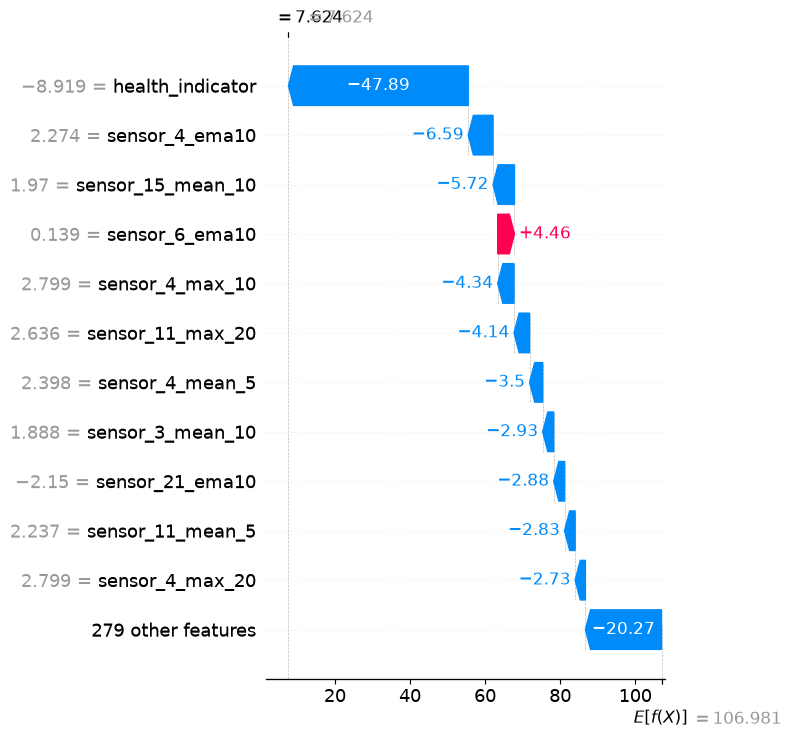

In [6]:
low_rul_idx = val.loc[X_sample.index, "RUL"].sort_values().index[0]
row_position = X_sample.index.get_loc(low_rul_idx)

engine_id = val.loc[low_rul_idx, "unit_number"]
cycle = val.loc[low_rul_idx, "cycle"]
true_rul = val.loc[low_rul_idx, "RUL"]
pred_rul = model.predict(X_val.loc[[low_rul_idx]])[0]
print(f"Engine {engine_id}, cycle {cycle}: true RUL = {true_rul}, predicted RUL = {pred_rul:.1f}")

shap.plots.waterfall(shap_values[row_position], max_display=12, show=False)
plt.tight_layout()
plt.show()


In [7]:
local_effects = pd.Series(shap_values.values[row_position], index=feature_cols).sort_values(key=np.abs, ascending=False).head(10)
local_table = local_effects.to_frame("shap_value")
local_table["feature_value"] = X_sample.iloc[row_position][local_table.index].values
local_table["direction"] = np.where(local_table["shap_value"] > 0, "raises predicted RUL", "lowers predicted RUL")
local_table


,shap_value,feature_value,direction
health_indicator,-47.886875,-8.919182,lowers predicted RUL
sensor_4_ema10,-6.586125,2.273697,lowers predicted RUL
sensor_15_mean_10,-5.721937,1.970425,lowers predicted RUL
sensor_6_ema10,4.461238,0.139020,raises predicted RUL
sensor_4_max_10,-4.340748,2.798654,lowers predicted RUL
sensor_11_max_20,-4.139293,2.635537,lowers predicted RUL
sensor_4_mean_5,-3.497218,2.398447,lowers predicted RUL
sensor_3_mean_10,-2.932865,1.887671,lowers predicted RUL
sensor_21_ema10,-2.881001,-2.149957,lowers predicted RUL
sensor_11_mean_5,-2.832442,2.236629,lowers predicted RUL


## Dependence plots for the top features

How does the prediction change as a single top feature varies, and does that relationship interact with another feature (color)?


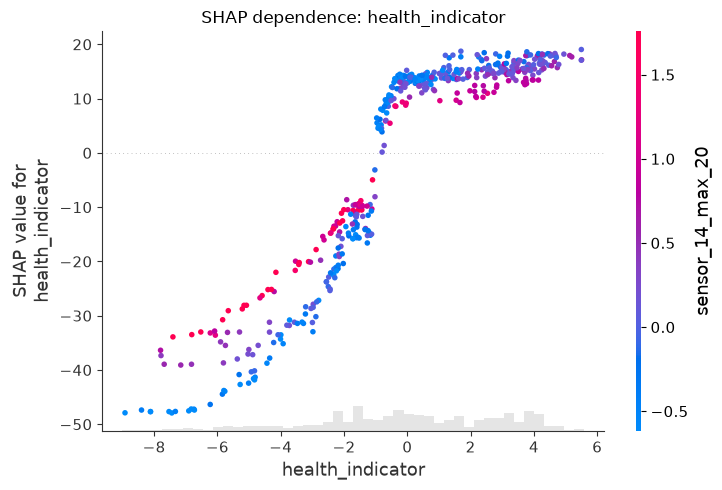

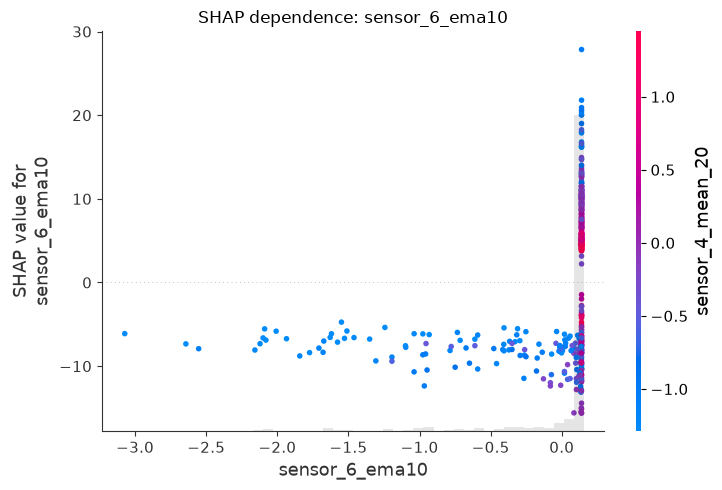

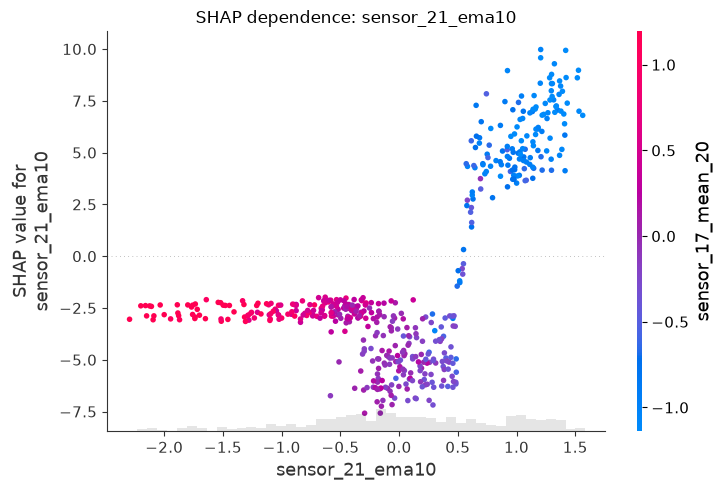

In [8]:
top_3 = mean_abs_shap.head(3).index.tolist()
for feat in top_3:
    shap.plots.scatter(shap_values[:, feat], color=shap_values, show=False)
    plt.title(f"SHAP dependence: {feat}")
    plt.tight_layout()
    plt.show()


## Caveat

SHAP explains what the **model** learned to rely on — it is not automatically the true physical failure mechanism, and correlated sensors (several C-MAPSS sensors move together physically) can make SHAP split credit between them in ways that don't map cleanly to a single root cause. Cross-check surprising SHAP findings against the domain knowledge in the PHM08 paper (`docs/Damage Propagation Modeling.pdf`) before treating them as mechanistic conclusions.


## Summary

- Explained the best tree model from `05_tree_models.ipynb` with an exact `TreeExplainer`.
- Global feature importance (bar + beeswarm) mapped back to physical sensor names/descriptions.
- A worked local example for one near-failure engine, with a plain-language table of which features raised/lowered its predicted RUL.
- Dependence plots for the top 3 features, plus an explicit caveat on correlation vs. causation.

**Next:** `08_failure_probability.ipynb` — health score, failure-probability classification, prediction intervals, and a final maintenance-recommendation table.
